# Module 16 — Preference Optimization (DPO / IPO): the loss, the β knob, the dual-model forward

A CPU-only walkthrough of the new content in this module:

1. **The DPO loss** on synthetic log-probabilities — what each term does, and what aligned vs misaligned actually looks like in numbers.
2. **The β knob** — how the KL anchor strength reshapes the loss curve.
3. **DPO vs IPO vs cDPO** — the three loss-link functions, side by side.
4. **The dual-model forward** — `gather_response_logps` + `forward_dpo` on a tiny real Qwen3.
5. **A few train steps** — watching the margin grow.
6. **Memory accounting** — why we hold two models in VRAM and what it costs.

No GPU and no network needed; this runs in a couple of minutes on CPU.

In [1]:
import sys, math
from pathlib import Path
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Make the module dir importable when the notebook is run from inside `16-preference-optimization/`
HERE = Path.cwd()
if HERE.name != "16-preference-optimization":
    HERE = HERE / "part-4-post-training" / "16-preference-optimization"
sys.path.insert(0, str(HERE))

from config import TrainConfig, PreferenceConfig
from loop import gather_response_logps, compute_dpo_loss, forward_dpo, train_step, IGNORE_INDEX

torch.manual_seed(0)
print("imports OK")

imports OK


## 1. The DPO loss in math

The DPO loss for a single `(prompt, chosen, rejected)` triple:

```
L = -log σ( β · [ (log π(y_w|x) - log π_ref(y_w|x))
                - (log π(y_l|x) - log π_ref(y_l|x)) ] )
  = -log σ( β · margin )

where  margin = chosen_logratio - rejected_logratio
```

`chosen_logratio` measures how much *more* probable the chosen response is under the policy than under the reference (its starting state). When the policy is unchanged from the reference, both log-ratios are 0 and `margin = 0` → `loss = -log σ(0) = log 2 ≈ 0.693`. That's the random baseline.

Training wants `margin > 0`. As the policy learns to push chosen up *and* rejected down, the margin grows and the loss decreases. When margin is very positive, σ(β · margin) → 1 and the loss → 0.

In [2]:
# Show the PreferenceConfig defaults — what knobs are exposed.
pref = PreferenceConfig()
print("PreferenceConfig defaults:")
for k, v in pref.__dict__.items():
    print(f"  {k:18s} = {v}")
print()
print("Whole-config defaults:")
cfg = TrainConfig()
cfg.sync()
print(f"  model.name          = {cfg.model.name}     (the policy — should be an SFT'd model)")
print(f"  model.ref_name      = {cfg.model.ref_name!r}    ('' -> same checkpoint as policy, frozen)")
print(f"  optimizer.lr        = {cfg.optimizer.lr}    (20× lower than SFT)")
print(f"  preference.beta     = {cfg.preference.beta}")
print(f"  training.total_steps= {cfg.training.total_steps}")

PreferenceConfig defaults:
  loss_type          = dpo
  beta               = 0.1
  label_smoothing    = 0.0
  reference_free     = False

Whole-config defaults:
  model.name          = Qwen/Qwen3-1.7B     (the policy — should be an SFT'd model)
  model.ref_name      = ''    ('' -> same checkpoint as policy, frozen)
  optimizer.lr        = 5e-07    (20× lower than SFT)
  preference.beta     = 0.1
  training.total_steps= 1000


## 2. The loss in numbers — aligned vs misaligned

We synthesize a batch of 4 preference pairs and compute the loss directly. We never need a real model to demonstrate the math: log-probabilities are just numbers.

In [3]:
# Aligned batch: the policy already prefers chosen over rejected.
# (logπ(chosen) > logπ_ref(chosen);  logπ(rejected) < logπ_ref(rejected))
torch.manual_seed(0)
policy_chosen   = torch.tensor([-10.0, -12.0,  -8.0,  -9.0])
policy_rejected = torch.tensor([-14.0, -16.0, -13.0, -15.0])
ref_chosen      = torch.tensor([-11.0, -13.0,  -9.0, -10.0])
ref_rejected    = torch.tensor([-13.0, -15.0, -12.0, -14.0])

loss_a, m_a = compute_dpo_loss(policy_chosen, policy_rejected,
                               ref_chosen,    ref_rejected,
                               beta=0.1)
print(f"ALIGNED:")
print(f"  loss        = {loss_a.item():.4f}   (random baseline = {math.log(2):.4f})")
print(f"  margins     = {m_a['margin'].tolist()}")
print(f"  accuracy    = {m_a['accuracy'].mean().item():.0%}  (= % pairs with margin > 0)")
print(f"  chosen_rew  = {m_a['chosen_rewards'].mean().item():+.3f}")
print(f"  reject_rew  = {m_a['rejected_rewards'].mean().item():+.3f}")

# Misaligned: swap chosen and rejected on the policy side.
loss_m, m_m = compute_dpo_loss(policy_rejected, policy_chosen,
                               ref_chosen,      ref_rejected,
                               beta=0.1)
print(f"\nMISALIGNED (we swapped policy's chosen <-> rejected):")
print(f"  loss        = {loss_m.item():.4f}   (much higher — log-sigmoid penalty)")
print(f"  margins     = {m_m['margin'].tolist()}")
print(f"  accuracy    = {m_m['accuracy'].mean().item():.0%}")
print(f"  chosen_rew  = {m_m['chosen_rewards'].mean().item():+.3f}  (now negative)")
print(f"  reject_rew  = {m_m['rejected_rewards'].mean().item():+.3f}  (now positive)")

ALIGNED:
  loss        = 0.5981   (random baseline = 0.6931)
  margins     = [2.0, 2.0, 2.0, 2.0]
  accuracy    = 100%  (= % pairs with margin > 0)
  chosen_rew  = +0.100
  reject_rew  = -0.100

MISALIGNED (we swapped policy's chosen <-> rejected):
  loss        = 1.1398   (much higher — log-sigmoid penalty)
  margins     = [-6.0, -6.0, -8.0, -10.0]
  accuracy    = 0%
  chosen_rew  = -0.375  (now negative)
  reject_rew  = +0.375  (now positive)


## 3. The β knob: how the anchor strength reshapes the loss

β scales the margin *inside* the sigmoid. Geometrically, lower β = flatter sigmoid = the loss only really cares when the margin is large; higher β = sharp sigmoid = small differences in logratio matter a lot.

Practically, β trades off "follow the preference signal" vs "stay near the reference". The Zephyr / Tülu default β=0.1 is what almost every published recipe uses.

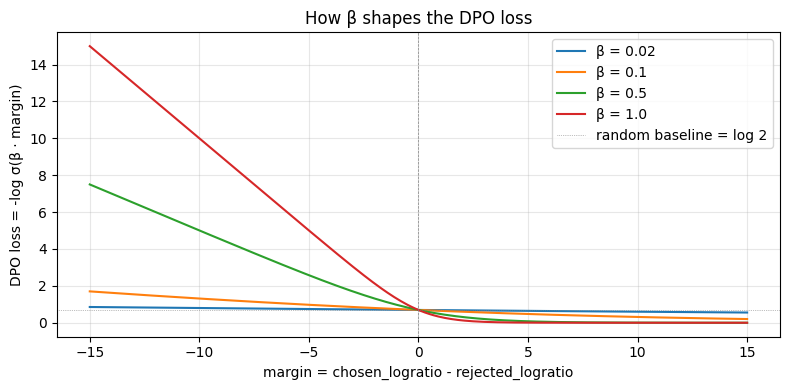

Read this plot left-to-right:
  - At margin = 0 every curve sits at log 2 ≈ 0.693 (the random baseline).
  - High β (1.0): the loss falls off a cliff around margin ≈ 0 — small drifts matter a lot.
  - Low β (0.02): the loss is nearly flat — the policy can drift far before the loss reacts.


In [4]:
margins = np.linspace(-15, 15, 301)
betas = [0.02, 0.1, 0.5, 1.0]

plt.figure(figsize=(8, 4))
for beta in betas:
    losses = -np.log(1.0 / (1.0 + np.exp(-beta * margins)))   # -log σ(β·m)
    plt.plot(margins, losses, label=f"β = {beta}")
plt.axvline(0, color="grey", linewidth=0.5, linestyle="--")
plt.axhline(math.log(2), color="grey", linewidth=0.5, linestyle=":",
            label="random baseline = log 2")
plt.xlabel("margin = chosen_logratio - rejected_logratio")
plt.ylabel("DPO loss = -log σ(β · margin)")
plt.title("How β shapes the DPO loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Read this plot left-to-right:")
print("  - At margin = 0 every curve sits at log 2 ≈ 0.693 (the random baseline).")
print("  - High β (1.0): the loss falls off a cliff around margin ≈ 0 — small drifts matter a lot.")
print("  - Low β (0.02): the loss is nearly flat — the policy can drift far before the loss reacts.")

## 4. DPO vs IPO vs cDPO

Three loss-link functions on the same logratio difference (`margin`):

- **DPO**: `-log σ(β · margin)`. Sharp; pushes margin to +∞; can over-fit unanimous-preference pairs.
- **IPO**: `(margin - 1/(2β))²`. Bounded; asks for a SPECIFIC margin and penalizes overshoot — robust to noisy labels.
- **cDPO**: DPO with label_smoothing α — convex combination treating the chosen-preferred event as `(1-α)` probable and the rejected-preferred event as `α`. Useful when ~10-20% of your preference labels are noisy.

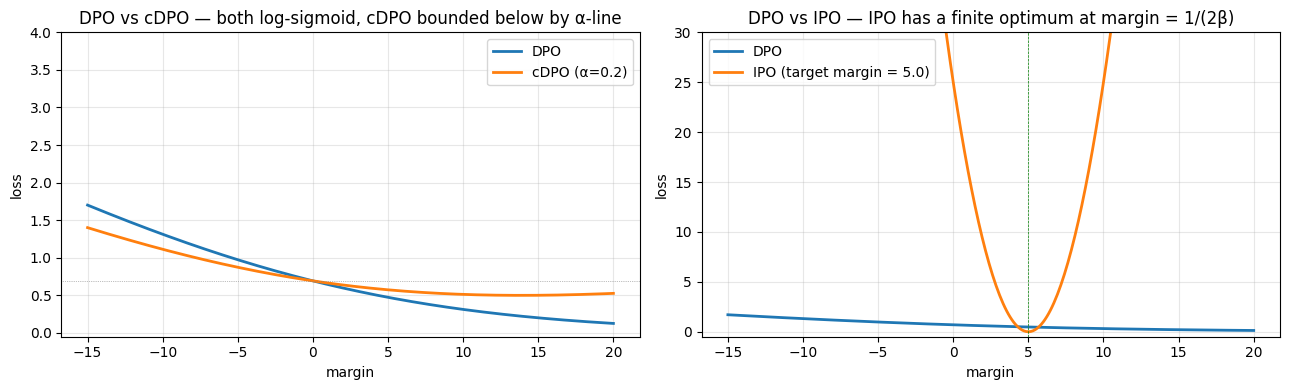

Note: DPO asks the model to push margin to +∞; IPO asks for a SPECIFIC margin (1/(2β) = 5).
Past that, IPO penalizes going further — built-in protection against over-confidence.


In [5]:
margins = np.linspace(-15, 20, 301)
beta = 0.1
target_margin = 1.0 / (2.0 * beta)   # IPO's bottom = 5.0
alpha = 0.2                          # cDPO label smoothing

dpo_losses  = -np.log(1.0 / (1.0 + np.exp(-beta * margins)))
ipo_losses  = (margins - target_margin) ** 2
# cDPO: -(1-α) log σ(β m) - α log σ(-β m)
sig_pos = 1.0 / (1.0 + np.exp(-beta * margins))
sig_neg = 1.0 / (1.0 + np.exp( beta * margins))
cdpo_losses = -(1 - alpha) * np.log(sig_pos) - alpha * np.log(sig_neg)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(margins, dpo_losses, label="DPO", linewidth=2)
axes[0].plot(margins, cdpo_losses, label=f"cDPO (α={alpha})", linewidth=2)
axes[0].set_xlabel("margin"); axes[0].set_ylabel("loss")
axes[0].set_title("DPO vs cDPO — both log-sigmoid, cDPO bounded below by α-line")
axes[0].axhline(math.log(2), color="grey", linewidth=0.5, linestyle=":")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_ylim(-0.05, 4)

axes[1].plot(margins, dpo_losses, label="DPO", linewidth=2)
axes[1].plot(margins, ipo_losses, label=f"IPO (target margin = {target_margin})", linewidth=2)
axes[1].axvline(target_margin, color="green", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("margin"); axes[1].set_ylabel("loss")
axes[1].set_title("DPO vs IPO — IPO has a finite optimum at margin = 1/(2β)")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(-0.5, 30)

plt.tight_layout()
plt.show()
print("Note: DPO asks the model to push margin to +∞; IPO asks for a SPECIFIC margin (1/(2β) = 5).")
print("Past that, IPO penalizes going further — built-in protection against over-confidence.")

## 5. From numbers to a real model — `gather_response_logps`

In real training, those `policy_chosen_logps` and `ref_chosen_logps` aren't free-floating numbers — they come from running the model's forward, taking log-softmax over the vocabulary at every position, and summing the per-token log-probs over the response tokens (the positions where `labels != IGNORE_INDEX`).

`gather_response_logps` does exactly that. Let's see it on a tiny synthetic batch.

In [6]:
# Synthesize logits and labels. Label IGNORE_INDEX (-100) means "don't include this position".
B, S, V = 2, 6, 8
logits = torch.randn(B, S, V)
labels = torch.full((B, S), IGNORE_INDEX, dtype=torch.long)
labels[0, 2] = 3; labels[0, 3] = 5; labels[0, 4] = 1   # example 0 has 3 response tokens
labels[1, 1] = 0; labels[1, 2] = 7                     # example 1 has 2 response tokens

logps = gather_response_logps(logits, labels)
print(f"logps[0] = {logps[0].item():.4f}  (sum of log-prob at positions 2,3,4 over their target tokens)")
print(f"logps[1] = {logps[1].item():.4f}  (sum of log-prob at positions 1,2 over their target tokens)")

# Verify by hand-computing
log_probs = torch.log_softmax(logits.float(), dim=-1)
expected_0 = log_probs[0, 2, 3] + log_probs[0, 3, 5] + log_probs[0, 4, 1]
expected_1 = log_probs[1, 1, 0] + log_probs[1, 2, 7]
print(f"\nHand-computed:")
print(f"  example 0 expected = {expected_0.item():.4f}")
print(f"  example 1 expected = {expected_1.item():.4f}")

logps[0] = -5.2653  (sum of log-prob at positions 2,3,4 over their target tokens)
logps[1] = -7.1339  (sum of log-prob at positions 1,2 over their target tokens)

Hand-computed:
  example 0 expected = -5.2653
  example 1 expected = -7.1339


## 6. End-to-end: forward through a real (tiny) Qwen3

Now we actually load a tiny Qwen3 (CPU, no download — just instantiate the architecture randomly) and run `forward_dpo` on a fake preference batch. This is the **same code path** that runs on the 1.7B model under torchrun — just at a scale that fits in this notebook.

In [7]:
from transformers import Qwen3Config, Qwen3ForCausalLM

cfg = Qwen3Config(
    vocab_size=512, hidden_size=64, num_hidden_layers=2,
    num_attention_heads=4, num_key_value_heads=2, intermediate_size=128,
    max_position_embeddings=64, tie_word_embeddings=True, use_cache=False,
)
policy = Qwen3ForCausalLM(cfg)
reference = Qwen3ForCausalLM(cfg)        # different random init -> non-trivial logratios
for p in reference.parameters():
    p.requires_grad_(False)
reference.eval()
print(f"policy params:    {sum(p.numel() for p in policy.parameters())/1e6:.2f}M")
print(f"reference params: {sum(p.numel() for p in reference.parameters())/1e6:.2f}M  (no grad)")

/home/antoniogrimaldi/projects/llm-lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


policy params:    0.28M
reference params: 0.28M  (no grad)


In [8]:
# Build a fake preference batch: B=2 pairs, seq_len=16, response is the last 5 positions.
B, S = 2, 16
torch.manual_seed(0)
labels_template = torch.full((B, S), IGNORE_INDEX, dtype=torch.long)
labels_template[:, S-5:] = torch.randint(0, cfg.vocab_size, (B, 5))   # response tokens

batch = {
    "chosen_input_ids":        torch.randint(0, cfg.vocab_size, (B, S)),
    "chosen_labels":           labels_template.clone(),
    "chosen_attention_mask":   torch.ones(B, S, dtype=torch.long),
    "rejected_input_ids":      torch.randint(0, cfg.vocab_size, (B, S)),
    "rejected_labels":         labels_template.clone(),
    "rejected_attention_mask": torch.ones(B, S, dtype=torch.long),
}

pref_cfg = PreferenceConfig(beta=0.1, loss_type="dpo")
loss, metrics = forward_dpo(policy, reference, batch, pref_cfg, dtype="fp32", device="cpu")

print("forward_dpo output:")
print(f"  loss                    {loss.item():.4f}")
print(f"  margin (chosen-rejected){metrics['margin'].mean().item():+.4f}")
print(f"  accuracy                {metrics['accuracy'].mean().item():.0%}")
print(f"  chosen_rewards (β·logr) {metrics['chosen_rewards'].mean().item():+.4f}")
print(f"  rejected_rewards        {metrics['rejected_rewards'].mean().item():+.4f}")
print(f"  loss.requires_grad      {loss.requires_grad}  (will be True — gradient flows back into the policy)")

forward_dpo output:
  loss                    0.7314
  margin (chosen-rejected)-0.7455
  accuracy                0%
  chosen_rewards (β·logr) -0.0371
  rejected_rewards        +0.0374
  loss.requires_grad      True  (will be True — gradient flows back into the policy)


## 7. A few train_steps — watch the margin grow

The same `train_step` function `train.py` calls. We give the policy a fixed batch and let it learn that those specific chosen tokens should be more probable than those specific rejected tokens.

Loss should fall, margin should rise, accuracy should approach 100%.

step  0  loss 0.7314  margin -0.746  acc 0%  r_ch -0.037  r_rej +0.037


step  5  loss 0.2951  margin +10.702  acc 100%  r_ch +0.523  r_rej -0.547
step 10  loss 0.2226  margin +13.899  acc 100%  r_ch +0.682  r_rej -0.708
step 15  loss 0.1841  margin +15.998  acc 100%  r_ch +0.785  r_rej -0.815


step 20  loss 0.1553  margin +17.845  acc 100%  r_ch +0.877  r_rej -0.907


step 25  loss 0.1307  margin +19.696  acc 100%  r_ch +0.967  r_rej -1.002


step 29  loss 0.1138  margin +21.167  acc 100%  r_ch +1.038  r_rej -1.078


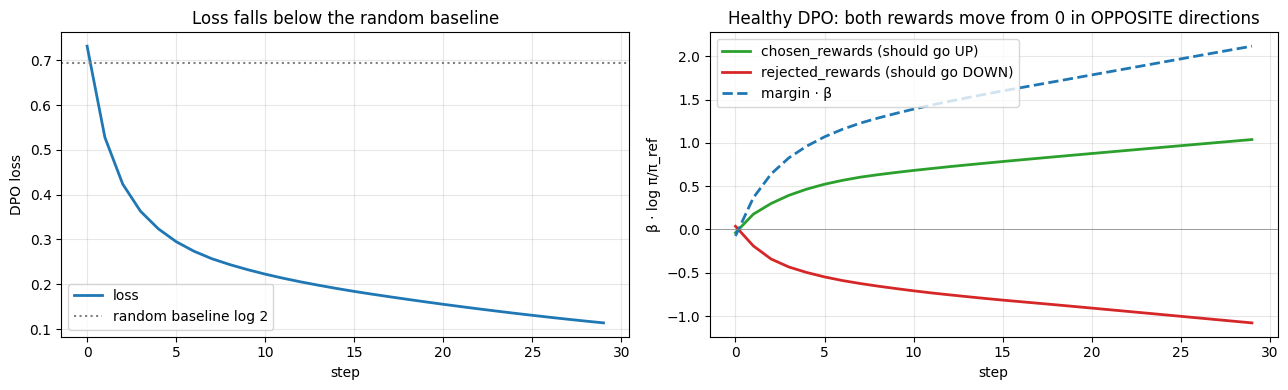

In [9]:
optimizer = torch.optim.AdamW(policy.parameters(), lr=5e-4)   # higher than real DPO — tiny model, fixed data

def batch_iter():
    while True:
        yield batch

history = {"step": [], "loss": [], "margin": [], "accuracy": [], "chosen_r": [], "rejected_r": []}
for step in range(30):
    stats = train_step(policy, reference, optimizer, batch_iter(),
                       grad_accum=1, grad_clip=1.0, pref_cfg=pref_cfg,
                       dtype="fp32", device="cpu")
    history["step"].append(step)
    history["loss"].append(stats["loss"])
    history["margin"].append(stats["margin"])
    history["accuracy"].append(stats["accuracy"])
    history["chosen_r"].append(stats["chosen_rewards"])
    history["rejected_r"].append(stats["rejected_rewards"])
    if step % 5 == 0 or step == 29:
        print(f"step {step:2d}  loss {stats['loss']:.4f}  margin {stats['margin']:+.3f}  "
              f"acc {stats['accuracy']:.0%}  r_ch {stats['chosen_rewards']:+.3f}  "
              f"r_rej {stats['rejected_rewards']:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["step"], history["loss"], label="loss", linewidth=2)
axes[0].axhline(math.log(2), color="grey", linestyle=":", label="random baseline log 2")
axes[0].set_xlabel("step"); axes[0].set_ylabel("DPO loss")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Loss falls below the random baseline")

axes[1].plot(history["step"], history["chosen_r"],   label="chosen_rewards (should go UP)",   linewidth=2, color="C2")
axes[1].plot(history["step"], history["rejected_r"], label="rejected_rewards (should go DOWN)", linewidth=2, color="C3")
axes[1].plot(history["step"], [c - r for c, r in zip(history["chosen_r"], history["rejected_r"])],
             label="margin · β", linewidth=2, color="C0", linestyle="--")
axes[1].axhline(0, color="grey", linewidth=0.5)
axes[1].set_xlabel("step"); axes[1].set_ylabel("β · log π/π_ref")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("Healthy DPO: both rewards move from 0 in OPPOSITE directions")

plt.tight_layout()
plt.show()

## 8. Memory accounting

DPO holds TWO models in VRAM. The reference is BF16, no-grad, no optimizer, no FP32 master — so its footprint is small (`2 bytes/param`). The policy carries the full mixed-precision setup we used in SFT.

For Qwen3-1.7B with the default config on a single A100-80GB:

In [10]:
n_params = 1.7e9

components = [
    ("Policy: master weights (FP32)",        4,   "policy",    n_params),
    ("Policy: compute weights (BF16)",       2,   "policy",    n_params),
    ("Policy: gradients (BF16)",             2,   "policy",    n_params),
    ("Policy: AdamW state (FP32 m + v)",     8,   "policy",    n_params),
    ("Reference: BF16 only, no grad/opt",    2,   "reference", n_params),
]
print(f"{'Component':<42s} {'Bytes/param':>12s} {'GB':>8s}")
print("-" * 64)
totals = {"policy": 0.0, "reference": 0.0}
for name, bytes_per, which, np_ in components:
    gb = bytes_per * np_ / 1e9
    totals[which] += gb
    print(f"{name:<42s} {bytes_per:>12d} {gb:>8.2f}")
print("-" * 64)
print(f"{'Policy subtotal':<42s} {'':>12s} {totals['policy']:>8.2f}")
print(f"{'Reference subtotal':<42s} {'':>12s} {totals['reference']:>8.2f}")
weights = totals['policy'] + totals['reference']
print(f"{'Weights/grads/opt total':<42s} {'':>12s} {weights:>8.2f}")
# Activations: rough heuristic from Module 10. seq_len=1024, eff bs=4 (2 pairs × 2 sides), 1.7B.
# With activation checkpointing, ~3-4x lower than without.
acts_with_ac = 8.0
print(f"{'Activations (with AC, seq=1024, bs=4)':<42s} {'':>12s} {acts_with_ac:>8.2f}")
total = weights + acts_with_ac
print(f"{'TOTAL per rank':<42s} {'':>12s} {total:>8.2f}")
print()
print(f"A100-80GB has 80 GB of HBM, so this leaves {80 - total:.0f} GB of headroom for the caching allocator + scratch.")

Component                                   Bytes/param       GB
----------------------------------------------------------------
Policy: master weights (FP32)                         4     6.80
Policy: compute weights (BF16)                        2     3.40
Policy: gradients (BF16)                              2     3.40
Policy: AdamW state (FP32 m + v)                      8    13.60
Reference: BF16 only, no grad/opt                     2     3.40
----------------------------------------------------------------
Policy subtotal                                            27.20
Reference subtotal                                          3.40
Weights/grads/opt total                                    30.60
Activations (with AC, seq=1024, bs=4)                       8.00
TOTAL per rank                                             38.60

A100-80GB has 80 GB of HBM, so this leaves 41 GB of headroom for the caching allocator + scratch.


## 9. Recap

What you've seen in this notebook:

| Cell | Idea |
|------|------|
| 2-4 | The DPO loss in numbers — aligned (margin > 0, loss low) vs misaligned (margin < 0, loss high). |
| 5-6 | The β knob reshapes the loss curve. Low β = flat = drift allowed; high β = sharp = tight anchor. |
| 7-8 | DPO vs IPO vs cDPO — three loss-link functions on the same logratio difference. |
| 9-10 | `gather_response_logps` — how those abstract "log-probabilities" come from a real model. |
| 11-12 | `forward_dpo` on a tiny Qwen3 — the full code path that runs on the 1.7B under torchrun. |
| 13-14 | A few `train_step`s — chosen reward goes up, rejected reward goes down, margin grows. |
| 15-16 | Memory accounting — why both models fit on an A100-80GB with activation checkpointing on. |

To go from this notebook to a real DPO run, edit `configs/dpo_qwen3_1.7b.yaml` (point at your SFT checkpoint), then:

```bash
torchrun --standalone --nproc_per_node=1 train.py --config=configs/dpo_qwen3_1.7b.yaml
```

Next module: **[GRPO](../17-reasoning-and-grpo/)** — the same dual-model machinery (policy + frozen reference + KL anchor) but with verified rewards and on-policy rollouts. You won't be teaching the model *which of two completions you wrote* is better; you'll be teaching it to generate completions that are *verifiably correct*.
